In [48]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv("insurance.csv")

In [50]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#EDA

In [51]:
df.shape

(1338, 7)

In [52]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [54]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [55]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [56]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

### We have to find the relations of other cols with the
### insurence charges column .

In [57]:
num_col = ['age', 'bmi', 'children', 'charges']

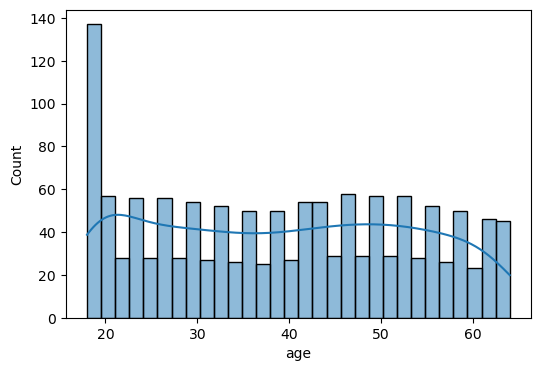

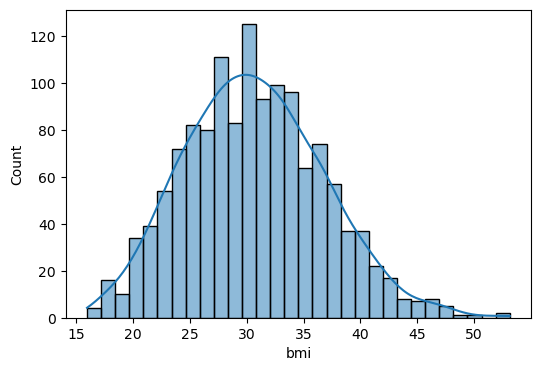

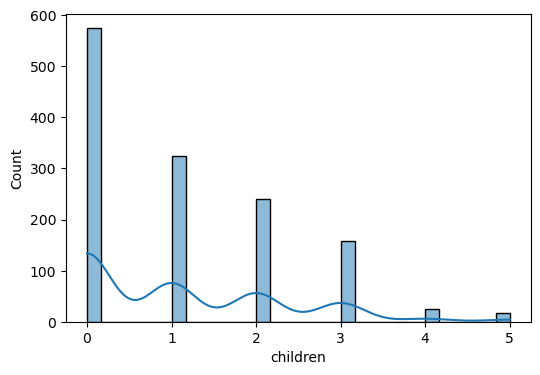

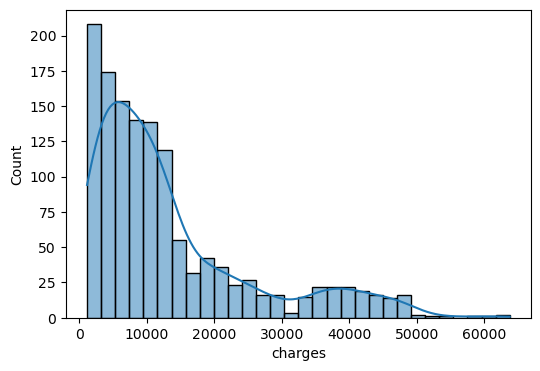

In [58]:
for cols in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[cols],kde=True,bins =30)

From the photoes we may see that :

1. There are a large amount of person under age 20,so ,they together might have larger ins. charges.

2. The 2nd pic shows , there are most of the people have bmi 25-35.

3. 3rd one shows , most have 0 child , then the other ,so , they might have less insurence charges.

4. There are most of the people with no child + less age + have a good bmi(health), so
 the number of people with less ins. charges is greater.

<Axes: xlabel='sex', ylabel='count'>

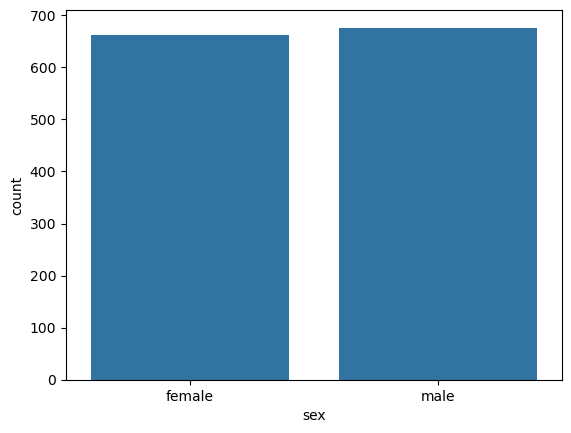

In [59]:
sns.countplot(x=df['sex'])

### Male and female numbers are quite equal,so , makes negligible effect on ins charges.

<Axes: xlabel='children', ylabel='count'>

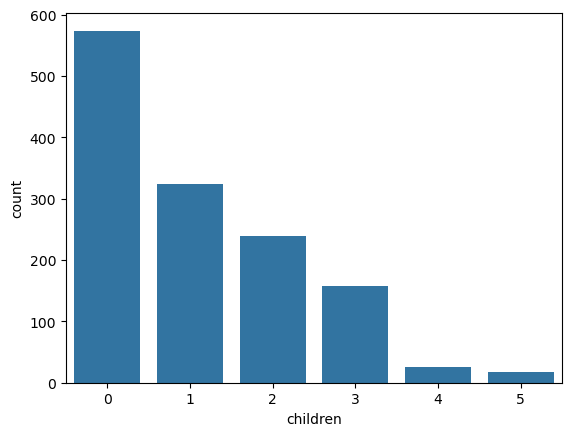

In [60]:
sns.countplot(x=df['children'])

<Axes: xlabel='smoker', ylabel='count'>

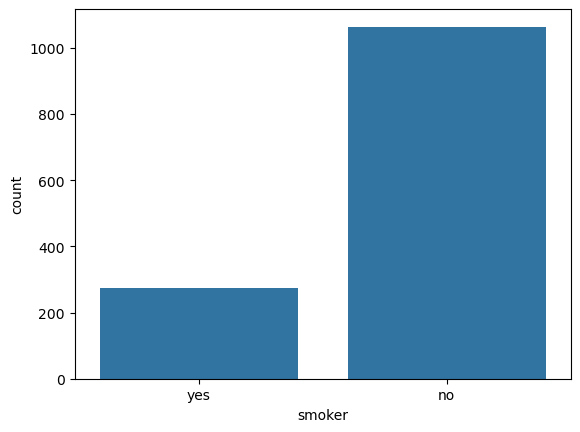

In [61]:
sns.countplot(x=df['smoker'])

### Usually, smokers have higher ins charges than non smokers.


### There are non smokers bigger in number , so , the number of people with less ins charges is larger

<Axes: xlabel='region', ylabel='count'>

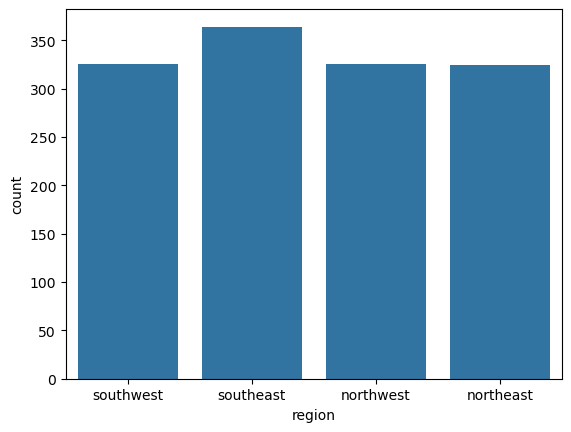

In [62]:
sns.countplot(x=df['region'])

### The poeple are almost equally distributed on regions,

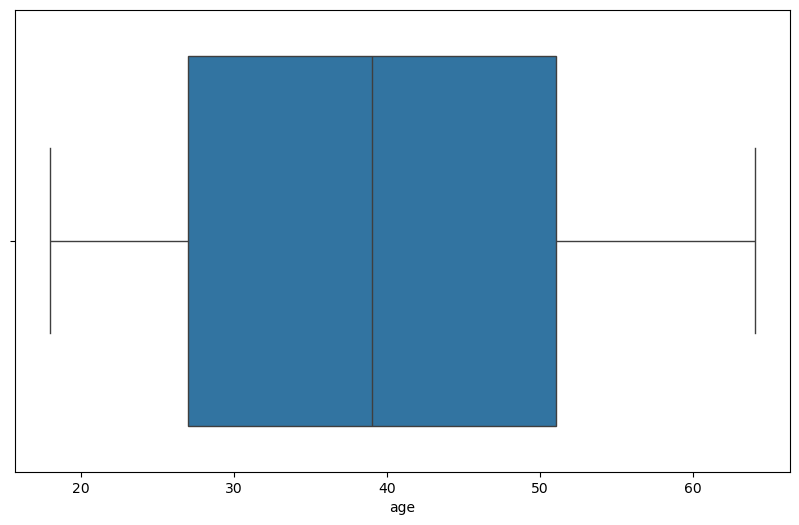

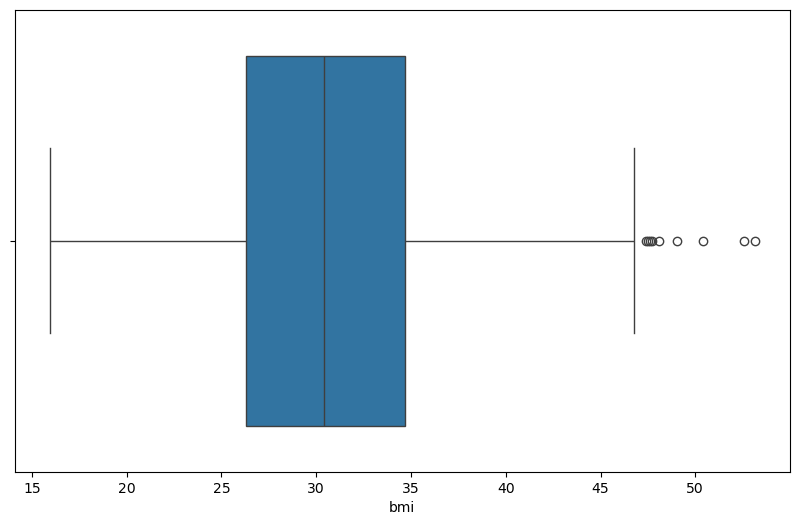

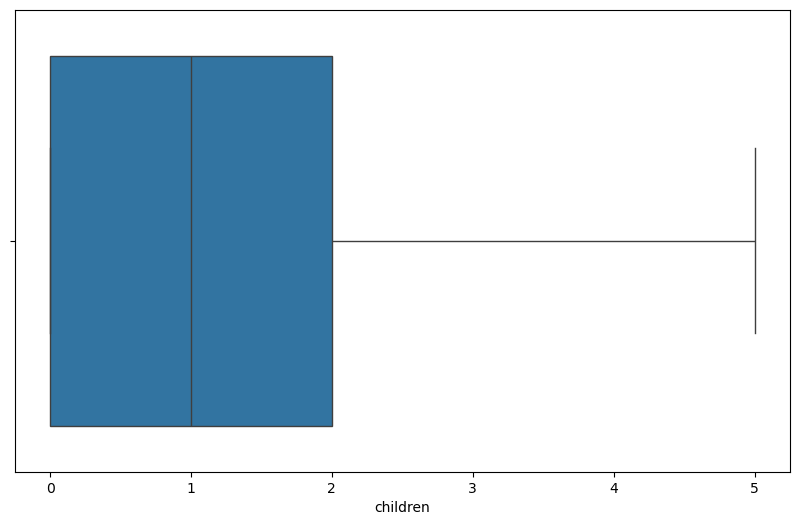

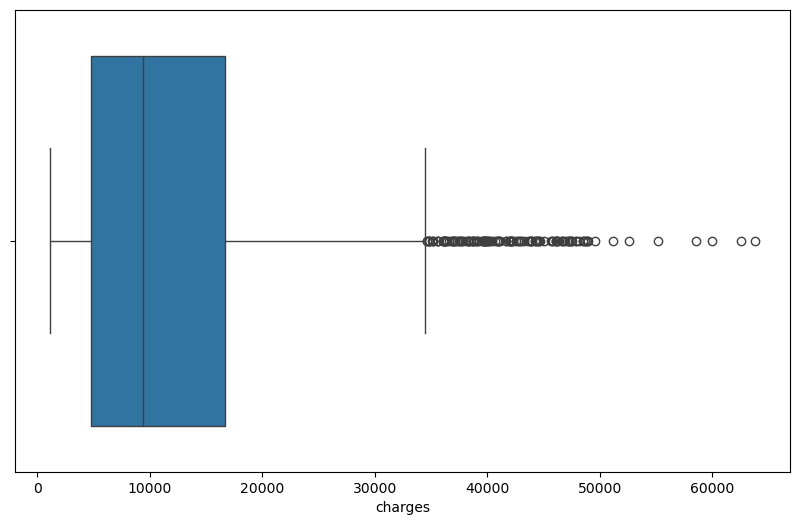

In [63]:
for cols in num_col:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df[cols])

1. The first pic is boxplot of age , 
 from the distribution curve , the age column is equally distribution.
 So , the boxplot is clean ,  nop outleir in age cols

2.The 2nd pic is boxplot of BMI , normal distribution , follows bel curve
most of the data lies between 25-35, and there is a small outleir between 45- 50 

3.No , outlier in children

4.There are massive amount of outleirs, 
 most of the data lies on under 20000,that is the boxplot , and there are another chunk of data between 40k-50k,
that are the outleirs

<Axes: >

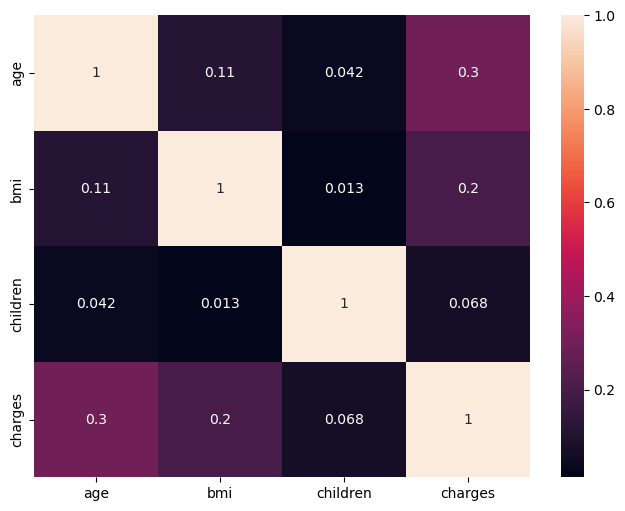

In [64]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

Data cleaning and pre-processing 

In [65]:
df2=df.copy()
df2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [66]:
df2.shape

(1338, 7)

The label encoding can be applied on "sex" column .
Setting Male=0 ; Female = 1 ;

In [67]:
df2["sex"].value_counts()

### If there exists m/male/Male/  and F/female/Female 

sex
male      676
female    662
Name: count, dtype: int64

In [68]:
df2.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [69]:
df2["sex"]=df2["sex"].map({"male" : 0 , "female" : 1})

In [70]:
df2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [71]:
df2["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [72]:
df2["smoker"] = df2["smoker"].map({"no" : 0 , "yes" : 1})

In [73]:
df2["smoker"].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

In [74]:
df2.rename(columns={
    "sex" : 'is_female',
    'smoker' : 'is_smoker' },inplace=True
          )

In [75]:
df2.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [76]:
df2["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

We have done label encoding for the yes/no values, where only two posibilities exixts.

But in the region column , there exists four posibilities .
So , there we apply the one hot encoding.[Read more about the one hot encoding]

In [77]:
df2=pd.get_dummies(df2,columns=['region'],drop_first=True)

In [78]:
df2=df2.astype(int)

In [79]:
df2

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


In [80]:
df2.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

# So , in data cleaning and preprocessing , we convert the string into numerial values,
# cause, machine learning algorithms only works with the numerical values.

# Feature engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

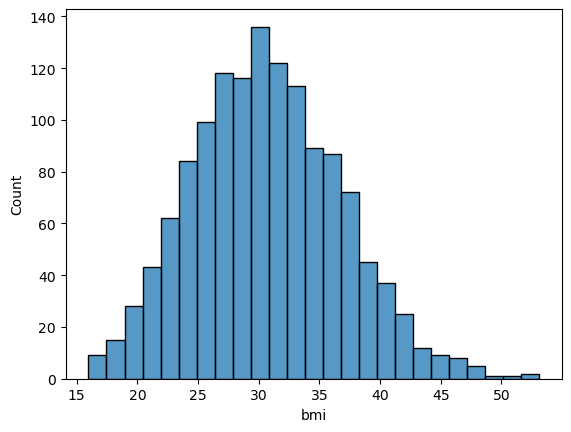

In [81]:
sns.histplot(df['bmi'])

we will create some bmi category based on BMI .

0-18.5     : Underweight 
18.5-24.9  : Normal
29.9-29.9  : Overweight
Above 29.9 : Obesity

In [82]:
df2['bmi_category'] = pd.cut(
    df2['bmi'],
    bins  = [0 , 18.5 , 24.9 ,29.9 ,float('inf')],
    labels= ['Underweight','Normal','Overweight','Obessed']
)

In [83]:
df2['bmi_category'].value_counts()

bmi_category
Obessed        707
Overweight     386
Normal         221
Underweight     24
Name: count, dtype: int64

In [84]:
df2=pd.get_dummies(df2,columns=['bmi_category'],drop_first=True)

In [85]:
df2

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obessed
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [86]:
df2=df2.astype(int)

In [87]:
df2.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obessed
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


# See,the data is far better .And, now, We have to perform a feature scaling on 'age' , 'bmi' , 'children' column.

# We have to import a library to perform feature scaling and a little bit of use of oops.


১. Feature Scaling কী? (What is it?)
মেশিন লার্নিং মডেলে যখন বিভিন্ন ফিচারের মান (Value) বিভিন্ন রেঞ্জে থাকে (যেমন: বয়স হতে পারে ২০-৭০, কিন্তু বেতন হতে পারে ২০,০০০-১,০০,০০০), তখন মডেলটি বড় মানের ফিচারকে বেশি গুরুত্ব দিয়ে ফেলে। সব ফিচারের মানকে একটি নির্দিষ্ট স্কেলে বা সীমার মধ্যে নিয়ে আসাকেই বলে Feature Scaling। 

Standardization নিচের গাণিতিক সূত্র মেনে চলে:$$z = \frac{x - \mu}{\sigma}$$যেখানে:$x$ হলো বর্তমান মান।$\mu$ হলো ওই কলামের গড় (Mean)।$\sigma$ হলো ওই কলামের স্ট্যান্ডার্ড ডেভিয়েশন (Standard Deviation)।

# এর ফলে ডেটার গড় হয় ০ এবং স্ট্যান্ডার্ড ডেভিয়েশন হয় ১।

In [88]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']

scaler = StandardScaler()

df2[cols] = scaler.fit_transform(df2[cols])

In [89]:
df2

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obessed
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,1,0,1,0
1,-1.509965,0,0.462657,-0.078767,0,1725,0,1,0,0,0,1
2,-0.797954,0,0.462657,1.580926,0,4449,0,1,0,0,0,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,1,0,0,1,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,-0.027733,1.580926,0,10600,1,0,0,0,0,1
1334,-1.509965,1,0.135731,-0.908614,0,2205,0,0,0,0,0,1
1335,-1.509965,1,0.953046,-0.908614,0,1629,0,1,0,0,0,1
1336,-1.296362,1,-0.845048,-0.908614,0,2007,0,0,1,0,1,0


In [90]:
import pandas as pd

correlations = df2.corr()['charges'].sort_values(ascending=True)

print("Correlation with Target Column:")
print(correlations)

Correlation with Target Column:
bmi_category_Overweight   -0.120084
bmi_category_Normal       -0.103679
is_female                 -0.057293
region_southwest          -0.043210
region_northwest          -0.039905
children                   0.067999
region_southeast           0.073981
bmi                        0.196188
bmi_category_Obessed       0.199533
age                        0.299009
is_smoker                  0.787251
charges                    1.000000
Name: charges, dtype: float64


# The highly co-related or negetively related (above or less 0.5) features can be used

# Learn z test, t test, chi square test , ANOVA test 

In [91]:
df2.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obessed'],
      dtype='object')

In [92]:
import pandas as pd
import scipy.stats as stats

cat_features = ['is_female', 'is_smoker', 
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obessed']

target_col = 'charges' 

anova_results = []

for col in cat_features:
    groups = [group[target_col].values for name, group in df2.groupby(col)]
    
    f_stat, p_val = stats.f_oneway(*groups)
    
    anova_results.append({
        'Feature': col,
        'F-Statistic': round(f_stat, 4),
        'P-Value': round(p_val, 10), 
        'Decision': 'Keep (Significant)' if p_val < 0.05 else 'Drop (Not Significant)'
    })

anova_df = pd.DataFrame(anova_results)
print("ANOVA Test Results:")
print(anova_df)

ANOVA Test Results:
                   Feature  F-Statistic   P-Value                Decision
0                is_female       4.3999  0.036128      Keep (Significant)
1                is_smoker    2177.6059  0.000000      Keep (Significant)
2         region_northwest       2.1309  0.144592  Drop (Not Significant)
3         region_southeast       7.3524  0.006783      Keep (Significant)
4         region_southwest       2.4991  0.114150  Drop (Not Significant)
5      bmi_category_Normal      14.5171  0.000145      Keep (Significant)
6  bmi_category_Overweight      19.5471  0.000011      Keep (Significant)
7     bmi_category_Obessed      55.3960  0.000000      Keep (Significant)


# NOw we will drop the not significant features and keep the significants one, and that data frame can be
# in machine learning model 

In [93]:
final_df = df2[['is_female', 'is_smoker',
        'region_southeast',
       'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obessed']]

In [94]:
final_df


,is_female,is_smoker,region_southeast,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obessed
0,1,1,0,0,1,0
1,0,0,1,0,0,1
2,0,0,1,0,0,1
3,0,0,0,1,0,0
4,0,0,0,0,1,0
...,...,...,...,...,...,...
1333,0,0,0,0,0,1
1334,1,0,0,0,0,1
1335,1,0,1,0,0,1
1336,1,0,0,0,1,0
